In [1]:

import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import random
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)

In [2]:
# Define model structure
def get_degofsep(x,y=0):
    if y==0:
        x = {x: y}
    if (z:={j:y+1 for i in adj_pairs if {*i}&{*x} for j in i if j not in x}):
        return get_degofsep({**x, **z}, y+1)
    else:
        return x


class PairsDataset(Dataset):
    def __init__(self, raw_pairs):
        self.raw_pairs = raw_pairs

    def __len__(self): 
        return len(self.raw_pairs)

    def __getitem__(self, idx):
        return tuple([torch.tensor(i) for i in self.raw_pairs[idx]])


def get_trainloader(thresh=0):
    subids = [0]+[loc_ids[k] for k,v in get_degofsep('AA').items() if v>=thresh]
    subpairs = [[i,float(j)]
                for i,j in pairs_dos 
                if all([k in subids for k in i]) and i[0]<i[1]]
    return DataLoader(PairsDataset(subpairs), 
                      shuffle=False, 
                      batch_size=len(subpairs), 
                      drop_last=True)


class CoordNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.coords = nn.Embedding(len(loc_ids), 2, padding_idx=0)
        with torch.no_grad():
            self.coords.weight.copy_(self.coords.weight.divide(1e7))
        self.dist = nn.PairwiseDistance()
    
    def forward(self, pair):
        x = self.coords(pair[:, 0])
        y = self.coords(pair[:, 1])
        return self.dist(x,y)
    
    def get_coords(self):
        return self.coords.weight.cpu().detach().numpy()


# Get training data - pairs of tokens and sqrt of degrees of separation
with open('../../aoc/2022/input/16.txt', 'r') as f:
    rawinput = f.read().strip()

adj_pairs = [(i.split()[1], k.replace(',','')) 
             for i in rawinput.split('\n') 
             for j in [i.split(';')[1].split()[4:]]
             for k in j]
loc_ids = dict(zip((z:=sorted({*sum([[*i] for i in adj_pairs], [])})), 
                   range(len(z))))
pairs_dos = [[[loc_ids[i],loc_ids[j]], k] 
             for i in loc_ids 
             for j,k in get_degofsep(i).items() if k]

# Initialize model object
model = CoordNet()

In [218]:
# #### Running a single record through the model in eval mode to check calculations ####
# # Get single training record for testing
# input_tensor = next(iter(trainloader))[0][[1]]
# print(input_tensor)

# # Push training record and model to GPU
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)
# input_tensor = input_tensor.to(device)

# # Set to eval mode (no training)
# model.eval()

# # Get output
# with torch.no_grad():
#     output = model(input_tensor)
# print(output)

# # Get current embeddings layer values
# emb_values = model.get_coords()

# # Get values for input pair
# input_pair_emb = [emb_values[i] for i in input_tensor.cpu().numpy()[0]]

# # Check model calculation
# print((np.sum((input_pair_emb[0]-input_pair_emb[1])**2)**0.5).item())

In [3]:
# Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
def loss_fn(predictions, targets):
    return torch.mean(torch.abs(predictions-targets) 
                      / torch.maximum(torch.minimum(predictions, targets), 
                                      torch.ones_like(targets)))
optimizer = optim.SGD(model.parameters(), lr=0.1)
loss_by_epoch = []

e=0
for thresh in range(9,-1,-1):
    print(thresh)
    trainloader = get_trainloader(thresh)
    ee=0
    while ee<51 or (z:=loss_by_epoch[-1:-52:-50])[1]-z[0]>0.02:
        for inputs, labels in trainloader:
            optimizer.zero_grad()
            outputs = model(inputs.to(device))
            loss = loss_fn(outputs, labels.to(device))
            loss.backward()
            optimizer.step()
        loss_by_epoch += [loss.item()]
        e += 1
        ee += 1
        print(f'Epoch {e}: Loss={loss_by_epoch[-1]:.4f}')

9
Epoch 1: Loss=5.5000
Epoch 2: Loss=5.4639
Epoch 3: Loss=5.4110
Epoch 4: Loss=5.3579
Epoch 5: Loss=5.3047
Epoch 6: Loss=5.2513
Epoch 7: Loss=5.1977
Epoch 8: Loss=5.1438
Epoch 9: Loss=5.0896
Epoch 10: Loss=5.0351
Epoch 11: Loss=4.9804
Epoch 12: Loss=4.9167
Epoch 13: Loss=4.8362
Epoch 14: Loss=4.7680
Epoch 15: Loss=4.7074
Epoch 16: Loss=4.6514
Epoch 17: Loss=4.5754
Epoch 18: Loss=4.5121
Epoch 19: Loss=4.4569
Epoch 20: Loss=4.4072
Epoch 21: Loss=4.3604
Epoch 22: Loss=4.0744
Epoch 23: Loss=3.7525
Epoch 24: Loss=3.5280
Epoch 25: Loss=3.3521
Epoch 26: Loss=3.2223
Epoch 27: Loss=3.1375
Epoch 28: Loss=3.0686
Epoch 29: Loss=3.0109
Epoch 30: Loss=2.9616
Epoch 31: Loss=2.9187
Epoch 32: Loss=2.8809
Epoch 33: Loss=2.8472
Epoch 34: Loss=2.8168
Epoch 35: Loss=2.7893
Epoch 36: Loss=2.7676
Epoch 37: Loss=2.7558
Epoch 38: Loss=2.7449
Epoch 39: Loss=2.7347
Epoch 40: Loss=2.7252
Epoch 41: Loss=2.7163
Epoch 42: Loss=2.7079
Epoch 43: Loss=2.7001
Epoch 44: Loss=2.6927
Epoch 45: Loss=2.6857
Epoch 46: Loss=2.

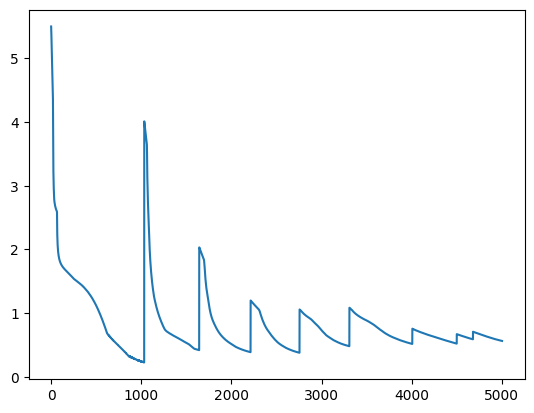

In [4]:
# Loss curve
plt.plot(range(len(loss_by_epoch)), loss_by_epoch)
plt.show()

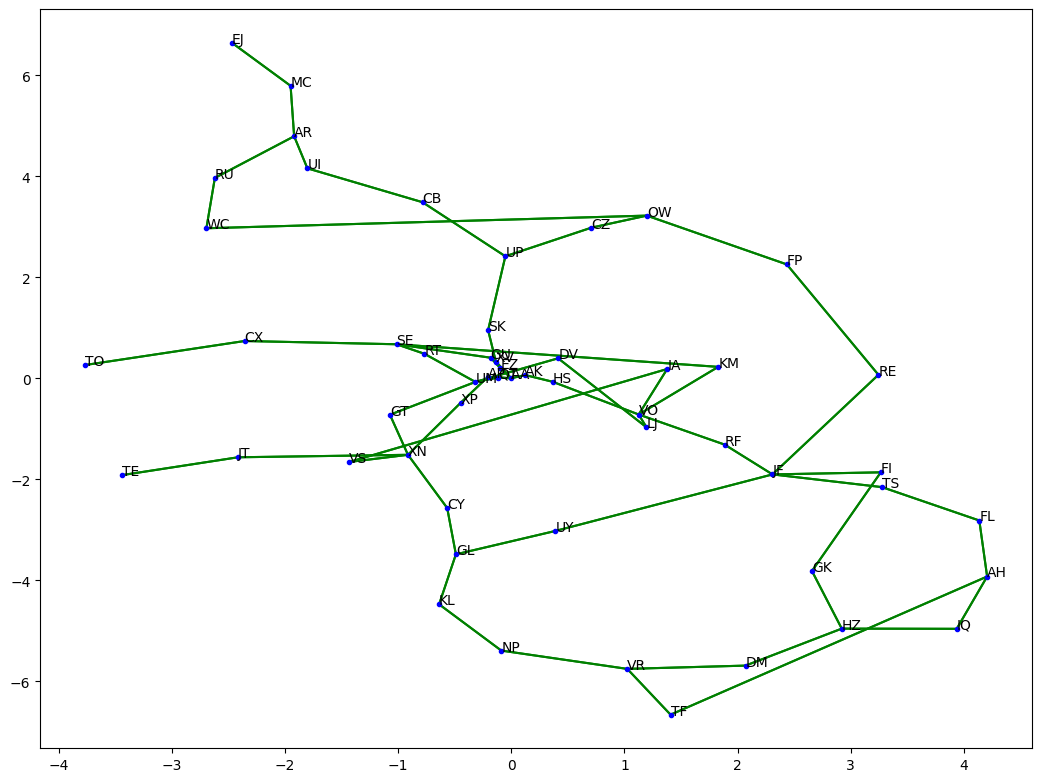

In [5]:
# Resulting coords
x,y = [np.squeeze(i,1) for i in np.hsplit(model.get_coords(), 2)]
plt.figure(figsize=(12.8, 9.6))
for p in adj_pairs:
    plt.plot([x[loc_ids[i]] for i in p], [y[loc_ids[i]] for i in p], 'g-')
plt.plot(x, y, 'b.')
for i,j in enumerate([*zip(*sorted([[v,k] for k,v in loc_ids.items()]))][1]):
    plt.annotate(j, (x[i], y[i]))
plt.show()